In [2]:
import xarray as xr
import numpy as np
import importlib
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score


import source.data_wrangling as dw
importlib.reload(dw)

<module 'source.data_wrangling' from '/home/jotje3041/thesis_2_electric_boogaloo/fystek-assignments/source/data_wrangling.py'>

## Notebook for the implementation and evaluation of the k-Nearest Neighbor algorithm

#### A simple example of the k-NN classification algorithm

In [3]:
def euclidean_distance(point1,point2):
    d_sum = np.sum((np.array(point1)-np.array(point2))**2)
    return np.sqrt(d_sum)



In [4]:
def kNN_predict(X_train,X_lab,test_point,k):
    '''
    K Nearest Neighbor prediction funcion

    Parameters
    ----------

    X_train : np.array[float]
        Training data 

    X_lab : np.array[int]
        Labels for training data, in this case likely array
        of values either 0, for normal or 1 for outlier
    
    test_point : float
        The data point which we are classifying

    k : int
        Hyperparameter for k-NN algorithm

    Returns
    -------

    label : int
        The predicted label for the test point

    '''
    dist = []

    for i in range(len(X_train)):
        d = euclidean_distance(test_point,X_train[i])
        dist.append((d,X_lab[i]))
    dist.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in dist[:k]]

    return Counter(k_nearest_labels).most_common(1)[0][0]

In [5]:
X_train = [[1,2],[2,3],[3,4],[6,7],[7,8]]
X_lab = ["A","A","A","B","B"]
lab_col = {"A":"blue",
           "B":"red"}

test_point = [4,5]
k = 3

In [6]:
prediction = kNN_predict(X_train,X_lab,test_point,k)
prediction

'A'

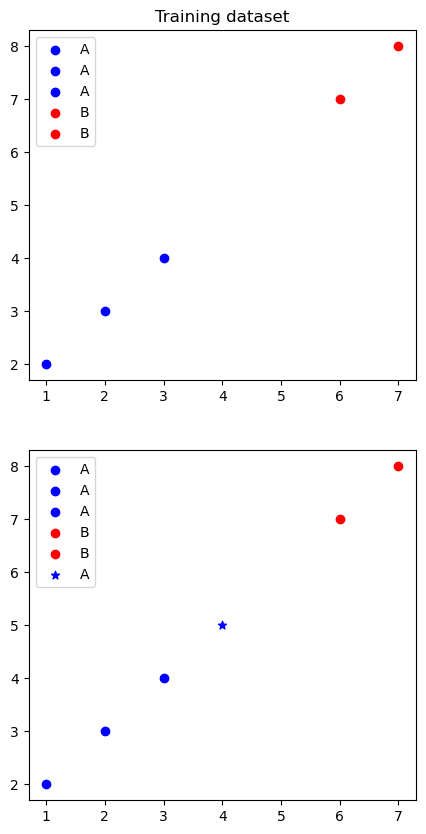

In [7]:
fig = plt.figure(figsize=(5,10))
ax = plt.subplot(2,1,1)
for idx in range(len(X_train)):
    col = lab_col[X_lab[idx]]
    ax.scatter(X_train[idx][0],X_train[idx][1],color=col,label=X_lab[idx])
ax.legend()
ax.set_title("Training dataset")

ax1 = plt.subplot(2,1,2)
for idx in range(len(X_train)):
    col = lab_col[X_lab[idx]]
    ax1.scatter(X_train[idx][0],X_train[idx][1],color=col,label=X_lab[idx])
ax1.scatter(test_point[0],test_point[1],color=lab_col[prediction],label=prediction,marker="*")
ax1.legend()
plt.savefig("figures/knn_results/test_case_knn.png")

#### k-NN Using sklearn

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#### Reading the data from 2025 & 2024

In [9]:
ds_2025 = xr.open_dataset("files/2025_KVS_deployment_flagged.nc")
ds_2024 = xr.open_dataset("files/2024_KVS_deployment_flagged.nc")

We calculate the difference between 1m temperature and surface temperature to train and classify based on the relationship between the surface and 1m temperature rather than just outliers in the 1m temperature

In [10]:
ds_2025_1m_temp = ds_2025["temp_1m_calibrated"]
ds_2025_ir_temp = ds_2025["temp_snowsurface"]
ds_2025["temp_diff"] = ds_2025_1m_temp - ds_2025_ir_temp

ds_2024_1m_temp = ds_2024["temp_1m_calibrated"]
ds_2024_ir_temp = ds_2024["temp_snowsurface_calibrated"]
ds_2024["temp_diff"] = ds_2024_1m_temp - ds_2024_ir_temp

Then pool all of the datapoints into one larger dataset that doesn't have the trajectory 

Select variables and pool the dataset, change units for 1-m temperature values

In [11]:
variables = ["temp_1m_calibrated","temp_diff","temp_1m_quality_flag","time_temp"]

In [12]:
dataset_2025 = dw.pool_data_variables(ds_2025,variables,[5,12,13],False)
dataset_2025["temp_1m_calibrated"] = dataset_2025["temp_1m_calibrated"]

In [13]:
dataset_2024 = dw.pool_data_variables(ds_2024,
                                      variables,
                                      [1, 2, 3, 4, 6, 7, 8, 10,
                                        12, 13, 14, 15, 16, 17, 18, 
                                        19, 21, 22, 23, 24, 25, 28, 32],
                                      False)
dataset_2024["temp_1m_calibrated"] = dataset_2024["temp_1m_calibrated"]

Structure feature matrix to contain 1m-temperature and temperature difference between 1m-temperature and surface

Set y values as the flags already contained in the file

In [14]:
data_2025 = dataset_2025[["temp_1m_calibrated","temp_diff"]]
labels_2025 = dataset_2025["temp_1m_quality_flag"]

In [15]:
data_2024 = dataset_2024[["temp_1m_calibrated","temp_diff"]]
labels_2024 = dataset_2024["temp_1m_quality_flag"]

#### Plot data features

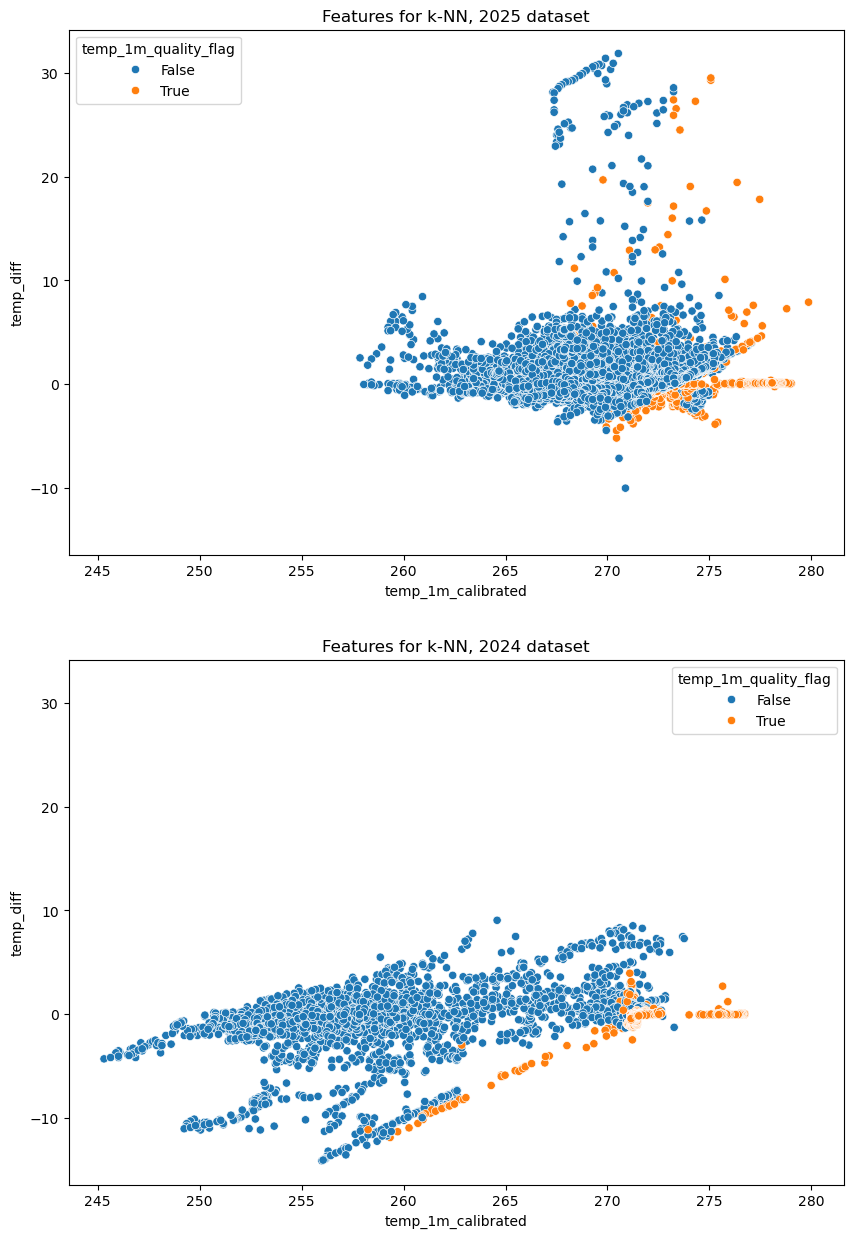

In [16]:
plt.figure(figsize=(10,15))
ax = plt.subplot(2,1,1)
sns.scatterplot(data=dataset_2025,
                x="temp_1m_calibrated",
                y="temp_diff",
                hue=labels_2025.astype(bool),
                ax=ax)
ax.set_title("Features for k-NN, 2025 dataset")

ax1 = plt.subplot(2,1,2,sharex=ax,sharey=ax)
sns.scatterplot(data=dataset_2024,
                x="temp_1m_calibrated",
                y="temp_diff",
                hue=labels_2024.astype(bool),
                ax=ax1)
ax1.set_title("Features for k-NN, 2024 dataset")

plt.savefig("figures/features_2024_2025_unscaled.png")

#### Scale data

In [17]:
min_val = np.min(data_2025["temp_diff"])
max_val = np.max(data_2025["temp_diff"])

data_2025["temp_diff"] = (data_2025["temp_diff"] - min_val) / (max_val - min_val)

min_val = np.min(data_2025["temp_1m_calibrated"])
max_val = np.max(data_2025["temp_1m_calibrated"])

data_2025["temp_1m_calibrated"] = (data_2025["temp_1m_calibrated"] - min_val) / (max_val - min_val)


/tmp/ipykernel_1440606/3000027033.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2025["temp_diff"] = (data_2025["temp_diff"] - min_val) / (max_val - min_val)
/tmp/ipykernel_1440606/3000027033.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2025["temp_1m_calibrated"] = (data_2025["temp_1m_calibrated"] - min_val) / (max_val - min_val)


In [18]:
min_val = np.min(data_2024["temp_diff"])
max_val = np.max(data_2024["temp_diff"])

data_2024["temp_diff"] = (data_2024["temp_diff"] - min_val) / (max_val - min_val)

min_val = np.min(data_2024["temp_1m_calibrated"])
max_val = np.max(data_2024["temp_1m_calibrated"])

data_2024["temp_1m_calibrated"] = (data_2024["temp_1m_calibrated"] - min_val) / (max_val - min_val)

/tmp/ipykernel_1440606/3245357064.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2024["temp_diff"] = (data_2024["temp_diff"] - min_val) / (max_val - min_val)
/tmp/ipykernel_1440606/3245357064.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2024["temp_1m_calibrated"] = (data_2024["temp_1m_calibrated"] - min_val) / (max_val - min_val)


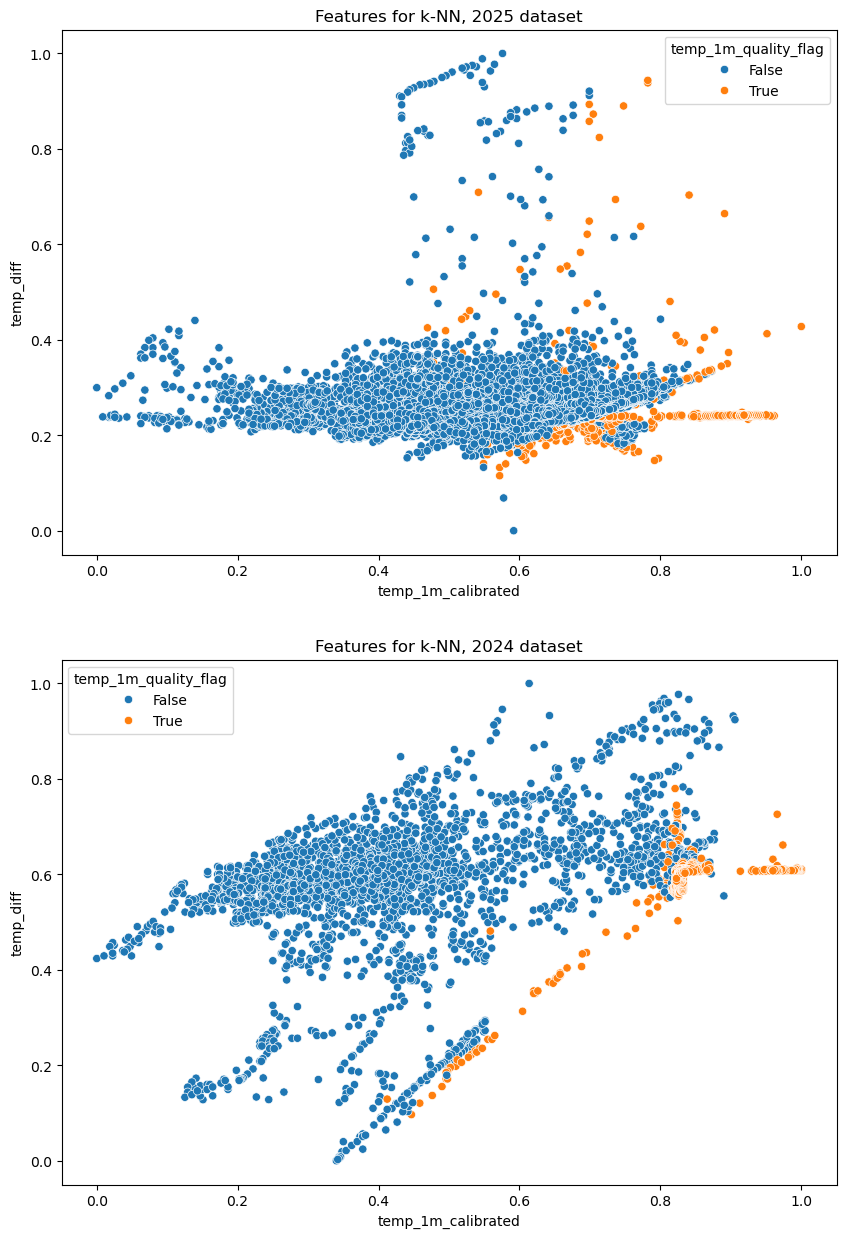

In [19]:
plt.figure(figsize=(10,15))
ax = plt.subplot(2,1,1)
sns.scatterplot(data=data_2025,
                x="temp_1m_calibrated",
                y="temp_diff",
                hue=labels_2025.astype(bool),
                ax=ax)
ax.set_title("Features for k-NN, 2025 dataset")

ax1 = plt.subplot(2,1,2,sharex=ax,sharey=ax)
sns.scatterplot(data=data_2024,
                x="temp_1m_calibrated",
                y="temp_diff",
                hue=labels_2024.astype(bool),
                ax=ax1)
ax1.set_title("Features for k-NN, 2024 dataset")

plt.savefig("figures/features_2024_2025_scaled.png")

### Test using only the 2025 data

In [20]:
train_data,test_data,train_labels,test_labels = train_test_split(data_2025,
                                                                 labels_2025,
                                                                 test_size=0.2)


In [21]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_data, train_labels)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
preds = knn.predict(test_data)
print(f"Test Accuracy (k=5): {accuracy_score(test_labels, preds):.2f}")

Test Accuracy (k=5): 0.95


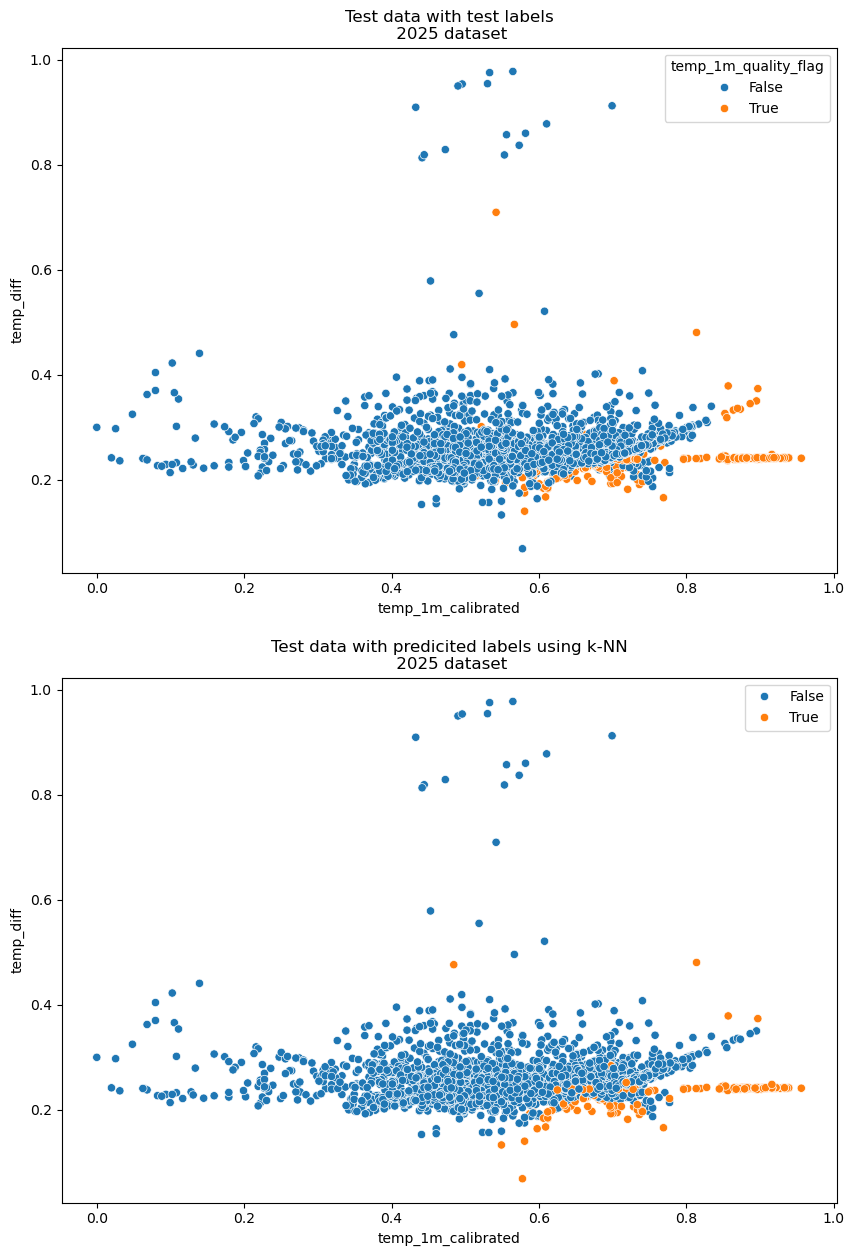

In [23]:
plt.figure(figsize=(10,15))
ax = plt.subplot(2,1,1)
sns.scatterplot(data=test_data,
                x="temp_1m_calibrated",
                y="temp_diff",
                hue=labels_2025.astype(bool),
                ax=ax)
ax.set_title("Test data with test labels\n 2025 dataset")

ax1 = plt.subplot(2,1,2)
sns.scatterplot(data=test_data,
                x="temp_1m_calibrated",
                y="temp_diff",
                hue=preds.astype(bool),
                ax=ax1)
ax1.set_title("Test data with predicited labels using k-NN\n 2025 dataset")

plt.savefig("figures/knn_results/results_train_test_2025_kNN.png")


### Choosing the optimal k value using cross validation

#### For the both datasets

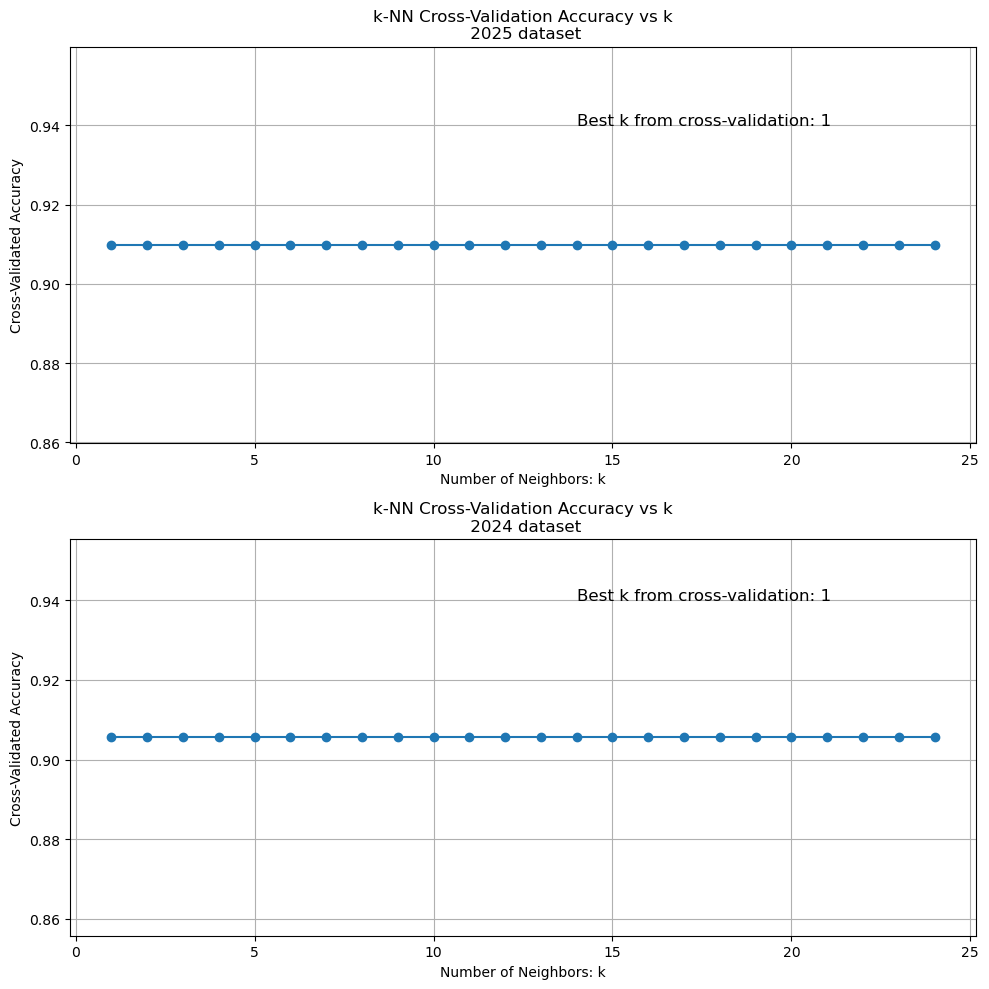

In [24]:
ks = range(1,25)

fig = plt.figure(figsize=(10,10))
ax = plt.subplot(2,1,1)

scores = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=5)
    scores_k = cross_val_score(knn, data_2025, labels_2025, cv=5, scoring='accuracy')
    scores.append(scores_k.mean())

ax.plot(ks, scores, marker='o')
ax.set_title("k-NN Cross-Validation Accuracy vs k\n 2025 dataset")
ax.set_xlabel("Number of Neighbors: k")
ax.set_ylabel("Cross-Validated Accuracy")
ax.grid(True)

best_k = ks[np.argmax(scores)]
ax.text(14,0.94,f"Best k from cross-validation: {best_k}",fontsize=12)


ax1 = plt.subplot(2,1,2)

scores = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=5)
    scores_k = cross_val_score(knn, data_2024, labels_2024, cv=5, scoring='accuracy')
    scores.append(scores_k.mean())

ax1.plot(ks, scores, marker='o')
ax1.set_title("k-NN Cross-Validation Accuracy vs k\n 2024 dataset")
ax1.set_xlabel("Number of Neighbors: k")
ax1.set_ylabel("Cross-Validated Accuracy")
ax1.grid(True)

best_k = ks[np.argmax(scores)]
ax1.text(14,0.94,f"Best k from cross-validation: {best_k}",fontsize=12)

plt.tight_layout()
plt.savefig("figures/knn_results/cross_val_knn_2024_2025.png")

### Using the 2025 dataset to flag the 2024 dataset

In [25]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(data_2025, labels_2025)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
flags_2024 = knn.predict(data_2024)

print(f"Accuracy: {accuracy_score(flags_2024, labels_2024):.2f}")

Accuracy: 0.81


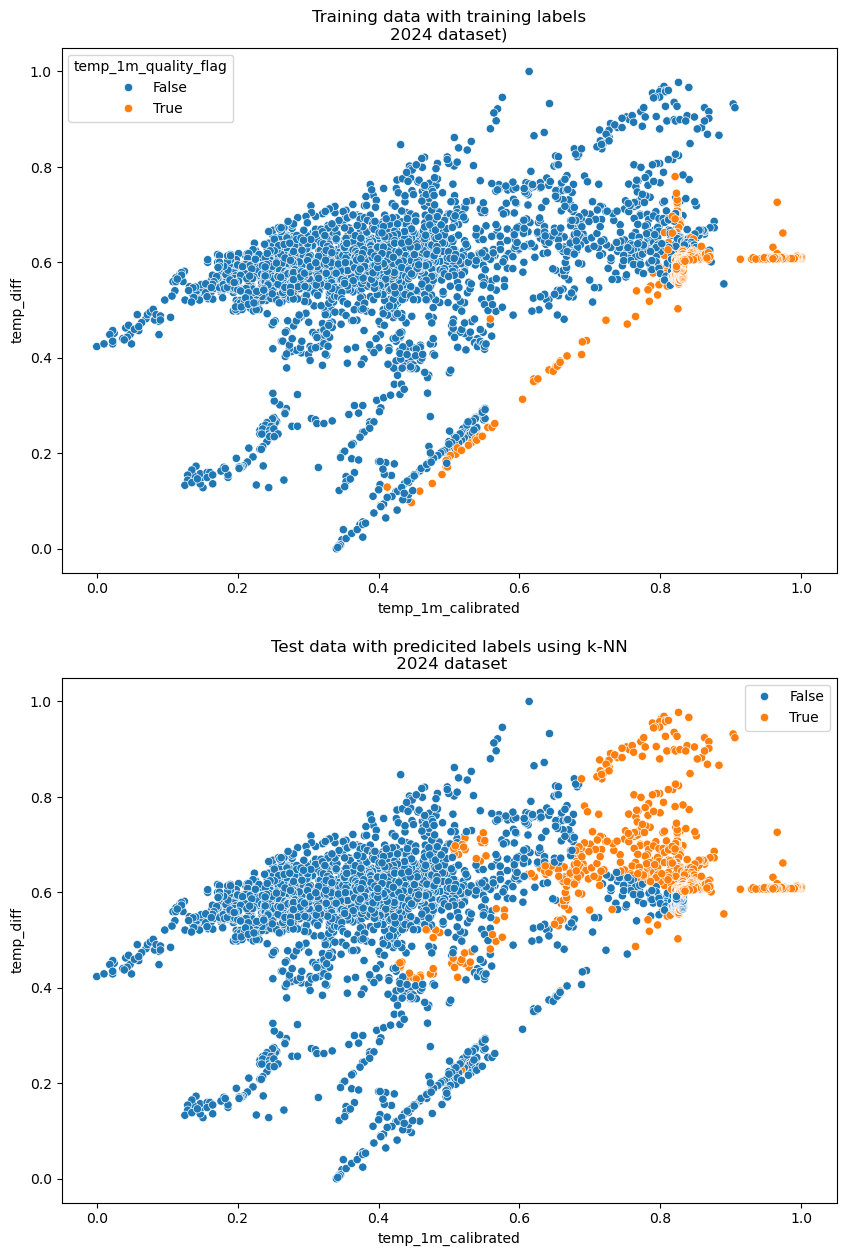

In [27]:
plt.figure(figsize=(10,15))
ax = plt.subplot(2,1,1)
sns.scatterplot(data=data_2024,
                x="temp_1m_calibrated",
                y="temp_diff",
                hue=labels_2024.astype(bool),
                ax=ax)
ax.set_title("Training data with training labels\n2024 dataset)")

ax1 = plt.subplot(2,1,2,sharex=ax,sharey=ax)
sns.scatterplot(data=data_2024,
                x="temp_1m_calibrated",
                y="temp_diff",
                hue=flags_2024.astype(bool),
                ax=ax1)
ax1.set_title("Test data with predicited labels using k-NN\n 2024 dataset")


plt.savefig("figures/knn_results/result_2024_flagging_kNN.png")